# Correlación de variables ambientales con el nivel estático y con los modelos de ML
**Pozo Finca El Socorro (Ovejas) — Acuífero Morroa**

Contenido:
1. Correlación (Pearson y Spearman) de las variables con el **nivel estático real**.
2. Modelos **Random Forest** y **XGBoost** con validación **cronológica** (`TimeSeriesSplit`), como plantea la metodología.
3. Correlación de las variables con la **salida de los modelos** (tablas, barras y mapas de calor).
4. **Métricas** de cada modelo: MAE, RMSE y R².
5. **Importancia de variables**: permutación y **SHAP**.

Los resultados se interpretan como **asociaciones**, no como causalidad.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

try:
    import shap
except ImportError:                      # en Colab puede no venir instalado
    !pip install shap -q
    import shap

RANDOM_STATE = 42
VARS = ["Precipitacion_mm", "NDVI", "EVI", "NDWI"]
ETIQ = {"Precipitacion_mm": "Precipitación", "NDVI": "NDVI", "EVI": "EVI", "NDWI": "NDWI"}

## 1. Carga y limpieza
Si estás en Colab, sube los dos Excel antes de correr.

In [2]:
ARCHIVO_AMBIENTAL = "Indices_Precipitacion_Feb_Oct_por_Ciudad.xlsx"
ARCHIVO_POZOS     = "Listado_de_los_Pozos_RESUME.xlsx"

df_amb_raw   = pd.read_excel(ARCHIVO_AMBIENTAL)
df_pozos_raw = pd.read_excel(ARCHIVO_POZOS)

def extraer_bloque(df, nombre_inicio, n_cols):
    cols = [c for c in df.columns if nombre_inicio.lower() in str(c).lower()]
    if not cols:
        raise ValueError(f"No encontré la columna '{nombre_inicio}'")
    i = df.columns.get_loc(cols[0])
    return df.iloc[:, i:i + n_cols].copy()

# Ambiental (Ovejas)
amb = extraer_bloque(df_amb_raw, "Ovejas", 6)
amb.columns = ["Fecha", "Temporada", "Precipitacion_mm", "NDVI", "EVI", "NDWI"]
amb["Fecha"] = pd.to_datetime(amb["Fecha"], errors="coerce")
amb = amb.dropna(subset=["Fecha"])
for c in VARS:
    amb[c] = pd.to_numeric(amb[c], errors="coerce")
amb = amb.sort_values("Fecha").reset_index(drop=True).rename(columns={"Fecha": "Fecha_Ambiental"})

# Pozo Finca El Socorro
pozo = extraer_bloque(df_pozos_raw, "Finca el socorro", 3)
pozo.columns = ["Fecha", "Nivel_Estatico_m", "Imputado"]
pozo["Fecha"] = pd.to_datetime(pozo["Fecha"], errors="coerce")
pozo = pozo.dropna(subset=["Fecha"])
pozo["Nivel_Estatico_m"] = pd.to_numeric(pozo["Nivel_Estatico_m"], errors="coerce")
pozo["Imputado"] = pd.to_numeric(pozo["Imputado"], errors="coerce").fillna(0).astype(int)
pozo = pozo.dropna(subset=["Nivel_Estatico_m"]).sort_values("Fecha").reset_index(drop=True)

print(f"Ambiental: {len(amb)} registros | Pozo: {len(pozo)} mediciones ({pozo.Imputado.sum()} imputadas)")

Ambiental: 30 registros | Pozo: 54 mediciones (11 imputadas)


## 2. Cruce temporal (backward)
Cada medición del pozo se une con el dato ambiental **anterior más reciente** (nunca con información posterior a la medición).

In [3]:
pozo_c = pozo[pozo["Fecha"] <= amb["Fecha_Ambiental"].max()].copy()
datos = pd.merge_asof(pozo_c, amb, left_on="Fecha", right_on="Fecha_Ambiental", direction="backward")
datos["Dias_Diferencia"] = (datos["Fecha"] - datos["Fecha_Ambiental"]).dt.days
datos = datos.dropna(subset=["Fecha_Ambiental"]).sort_values("Fecha").reset_index(drop=True)
sin_imp = datos[datos.Imputado == 0].reset_index(drop=True)

print(f"Filas: {len(datos)} | datos ambientales distintos: {datos.Fecha_Ambiental.nunique()}")
print(f"Sin imputados: {len(sin_imp)} filas")
print(f"Distancia al dato ambiental: mediana {datos.Dias_Diferencia.median():.0f} días, máx {datos.Dias_Diferencia.max()}")

Filas: 51 | datos ambientales distintos: 24
Sin imputados: 41 filas
Distancia al dato ambiental: mediana 93 días, máx 241


## 3. Correlación de las variables con el nivel estático real
Pearson (lineal) y Spearman (monótona, robusta a outliers).

In [4]:
def tabla_corr(d, objetivo="Nivel_Estatico_m"):
    filas = []
    for v in VARS:
        r, p = pearsonr(d[v], d[objetivo]); rho, ps = spearmanr(d[v], d[objetivo])
        filas.append({"Variable": v, "Pearson_r": r, "Pearson_p": p, "Spearman_rho": rho, "Spearman_p": ps, "n": len(d)})
    return pd.DataFrame(filas).round(4)

print("TODOS LOS DATOS"); display(tabla_corr(datos))
print("SIN IMPUTADOS");   display(tabla_corr(sin_imp))

TODOS LOS DATOS


,Variable,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,n
0,Precipitacion_mm,-0.0612,0.6694,-0.0147,0.9183,51
1,NDVI,-0.2443,0.0841,-0.3007,0.0320,51
2,EVI,-0.1450,0.3099,-0.2278,0.1078,51
3,NDWI,-0.2108,0.1376,-0.2431,0.0856,51


SIN IMPUTADOS


,Variable,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,n
0,Precipitacion_mm,-0.1219,0.4477,-0.0934,0.5612,41
1,NDVI,-0.2877,0.0681,-0.3637,0.0194,41
2,EVI,-0.1631,0.3081,-0.3155,0.0445,41
3,NDWI,-0.2466,0.1201,-0.3384,0.0305,41


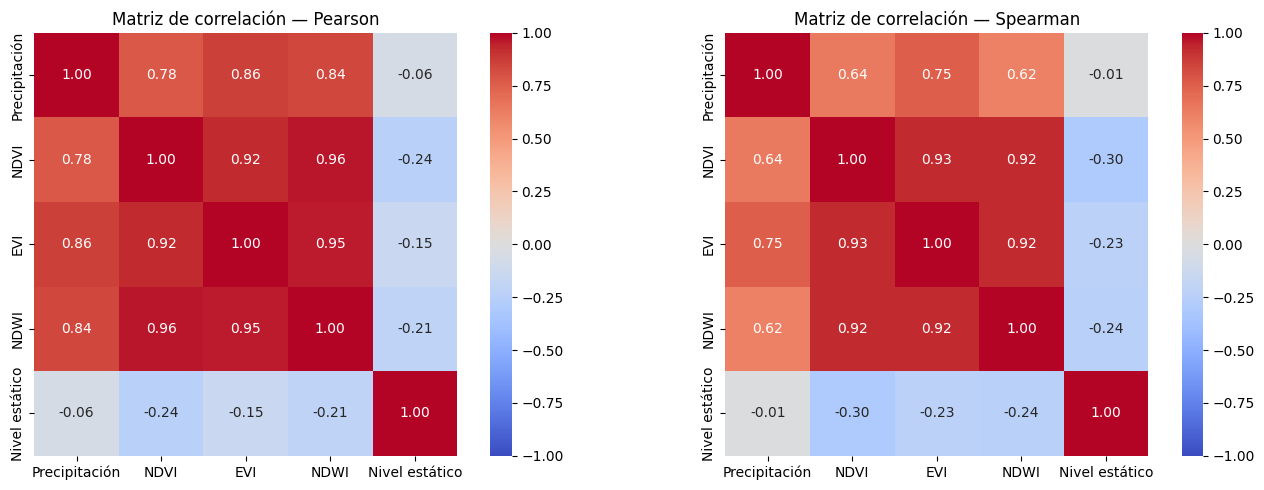

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, met in zip(axes, ["pearson", "spearman"]):
    m = datos[VARS + ["Nivel_Estatico_m"]].rename(columns={**ETIQ, "Nivel_Estatico_m": "Nivel estático"}).corr(method=met)
    sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f"Matriz de correlación — {met.capitalize()}")
plt.tight_layout(); plt.show()

## 4. Modelos con validación cronológica (`TimeSeriesSplit`)
**Cómo se valida:** ventana creciente en el tiempo. En cada fold el modelo se entrena con el pasado y se evalúa en un periodo posterior,
así nunca se usan observaciones futuras para predecir el pasado.

**Detalle importante:** varias mediciones del pozo comparten el mismo dato ambiental. Para que una misma `Fecha_Ambiental` no quede
dividida entre entrenamiento y prueba, la partición cronológica se hace sobre las **fechas ambientales distintas** y luego se asignan sus filas.

Consecuencia: las primeras filas solo se usan para entrenar; las predicciones (y todo lo que se calcula con ellas) corresponden a los periodos posteriores.
Como el modelo es determinista (`random_state` fijo), no hay repeticiones.

In [6]:
N_SPLITS = 5

def crear_modelos():
    return {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
        "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3,
                                random_state=RANDOM_STATE, objective="reg:squarederror"),
    }

def particion_cronologica(d, n_splits=N_SPLITS):
    fechas = np.sort(d["Fecha_Ambiental"].unique())
    splits = []
    for tr_g, te_g in TimeSeriesSplit(n_splits=n_splits).split(fechas):
        tr = np.where(d["Fecha_Ambiental"].isin(fechas[tr_g]))[0]
        te = np.where(d["Fecha_Ambiental"].isin(fechas[te_g]))[0]
        splits.append((tr, te))
    return splits

def evaluar_cronologico(d):
    """Predicciones fuera de muestra (cronológicas) de RF, XGB y un baseline (media del entrenamiento)."""
    X, y = d[VARS].values, d["Nivel_Estatico_m"].values
    splits = particion_cronologica(d)
    pred = {n: np.full(len(y), np.nan) for n in ["Baseline (media)", *crear_modelos()]}
    fold = np.full(len(y), -1)
    for k, (tr, te) in enumerate(splits):
        fold[te] = k
        pred["Baseline (media)"][te] = y[tr].mean()
        for nombre, mdl in crear_modelos().items():
            pred[nombre][te] = mdl.fit(X[tr], y[tr]).predict(X[te])
    return {"pred": pred, "fold": fold, "splits": splits}

res_todos = evaluar_cronologico(datos)
res_sin   = evaluar_cronologico(sin_imp)

for etiqueta, d, r in [("TODOS LOS DATOS", datos, res_todos), ("SIN IMPUTADOS", sin_imp, res_sin)]:
    usadas = r["fold"] >= 0
    print(f"{etiqueta}: {len(d)} filas | {usadas.sum()} con predicción fuera de muestra "
          f"({(~usadas).sum()} filas iniciales solo se usan para entrenar)")

TODOS LOS DATOS: 51 filas | 44 con predicción fuera de muestra (7 filas iniciales solo se usan para entrenar)
SIN IMPUTADOS: 41 filas | 34 con predicción fuera de muestra (7 filas iniciales solo se usan para entrenar)


## 5. Correlación de las variables con la salida de cada modelo
Responde: *¿qué variables se mueven junto con lo que el modelo "dice"?*
Se calcula sobre las predicciones fuera de muestra (cronológicas).

In [7]:
def corr_con_modelos(d, r):
    m = r["fold"] >= 0
    filas = []
    for v in VARS:
        fila = {"Variable": v}
        for nombre, k in [("Random Forest", "RF"), ("XGBoost", "XGB")]:
            p = r["pred"][nombre][m]
            pr, pp = pearsonr(d.loc[m, v], p); sr, sp = spearmanr(d.loc[m, v], p)
            fila.update({f"{k}_Pearson_r": pr, f"{k}_Pearson_p": pp, f"{k}_Spearman_rho": sr, f"{k}_Spearman_p": sp})
        filas.append(fila)
    return pd.DataFrame(filas).round(4)

print("TODOS LOS DATOS"); corr_mod_todos = corr_con_modelos(datos, res_todos);   display(corr_mod_todos)
print("SIN IMPUTADOS");   corr_mod_sin   = corr_con_modelos(sin_imp, res_sin);   display(corr_mod_sin)

TODOS LOS DATOS


,Variable,RF_Pearson_r,RF_Pearson_p,RF_Spearman_rho,RF_Spearman_p,XGB_Pearson_r,XGB_Pearson_p,XGB_Spearman_rho,XGB_Spearman_p
0,Precipitacion_mm,-0.5084,0.0004,-0.1194,0.4402,0.0723,0.6409,0.1638,0.2880
1,NDVI,-0.4747,0.0011,-0.3766,0.0117,-0.0457,0.7683,-0.1902,0.2163
2,EVI,-0.4967,0.0006,-0.2950,0.0519,0.1306,0.3980,0.0227,0.8835
3,NDWI,-0.5034,0.0005,-0.3111,0.0398,0.0206,0.8945,0.0052,0.9734


SIN IMPUTADOS


,Variable,RF_Pearson_r,RF_Pearson_p,RF_Spearman_rho,RF_Spearman_p,XGB_Pearson_r,XGB_Pearson_p,XGB_Spearman_rho,XGB_Spearman_p
0,Precipitacion_mm,-0.1634,0.3558,-0.0833,0.6397,0.2793,0.1097,0.1011,0.5696
1,NDVI,-0.3232,0.0623,-0.2742,0.1166,0.0979,0.5817,-0.1012,0.5690
2,EVI,-0.2980,0.0870,-0.2826,0.1054,0.2542,0.1469,0.0492,0.7823
3,NDWI,-0.3642,0.0342,-0.1218,0.4927,0.1440,0.4165,0.1800,0.3085


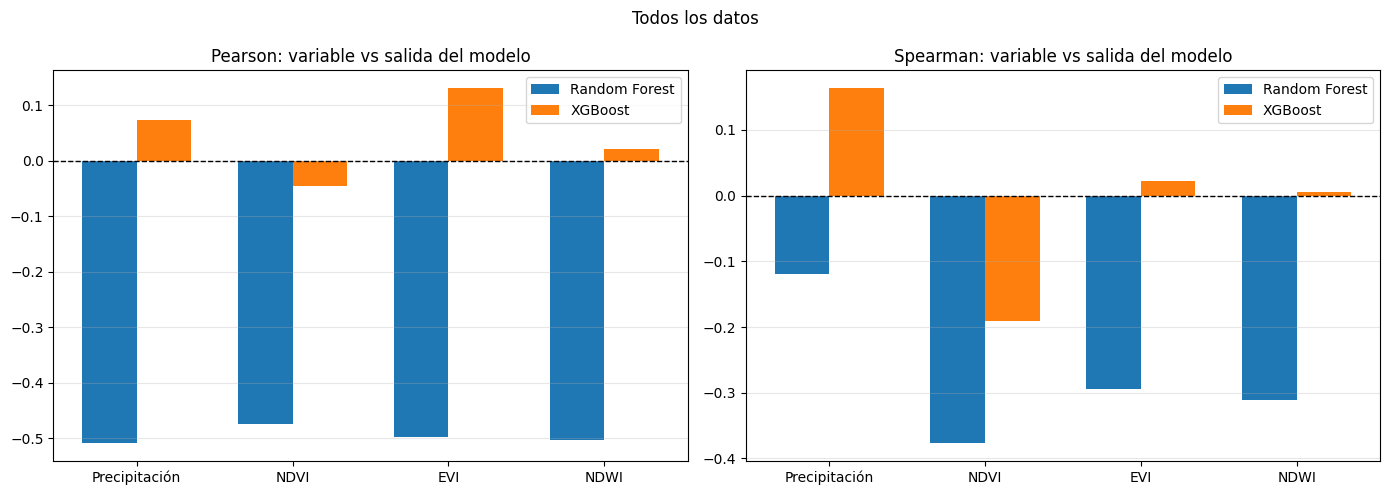

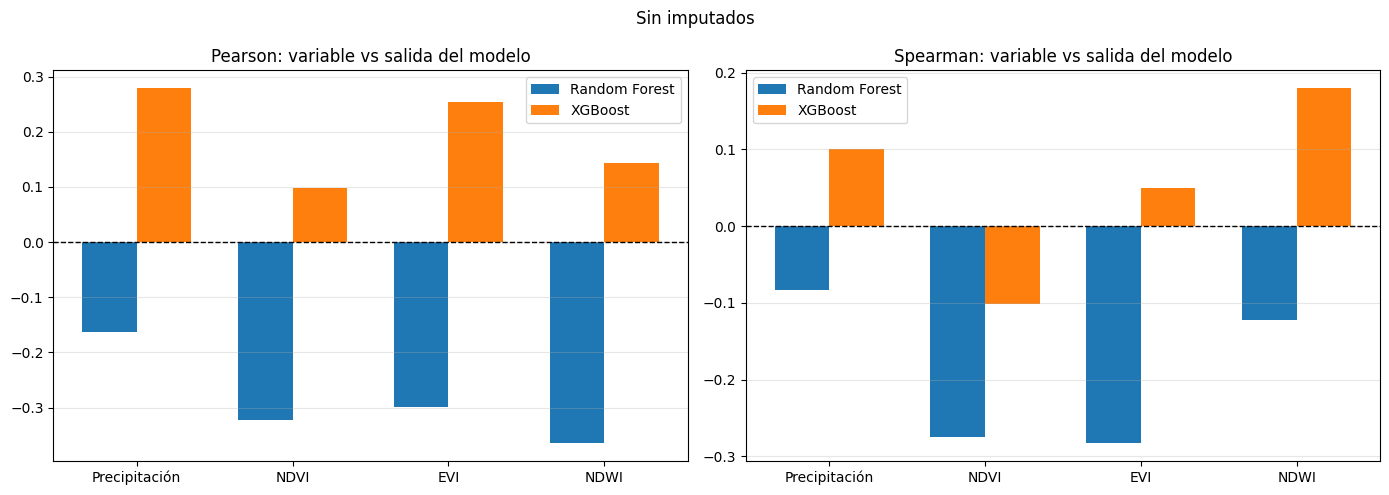

In [8]:
def barras(tabla, metrica, titulo, ax):
    x = np.arange(len(VARS)); ancho = 0.35
    ax.bar(x - ancho/2, tabla[f"RF_{metrica}"],  ancho, label="Random Forest")
    ax.bar(x + ancho/2, tabla[f"XGB_{metrica}"], ancho, label="XGBoost")
    ax.axhline(0, ls="--", lw=1, color="k")
    ax.set_xticks(x); ax.set_xticklabels([ETIQ[v] for v in VARS])
    ax.set_title(titulo); ax.grid(axis="y", alpha=.3); ax.legend()

for etiqueta, tabla in [("Todos los datos", corr_mod_todos), ("Sin imputados", corr_mod_sin)]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    barras(tabla, "Pearson_r",    "Pearson: variable vs salida del modelo",  axes[0])
    barras(tabla, "Spearman_rho", "Spearman: variable vs salida del modelo", axes[1])
    plt.suptitle(etiqueta); plt.tight_layout(); plt.show()

### 5.1 Mapa de calor: variables vs salida de los modelos

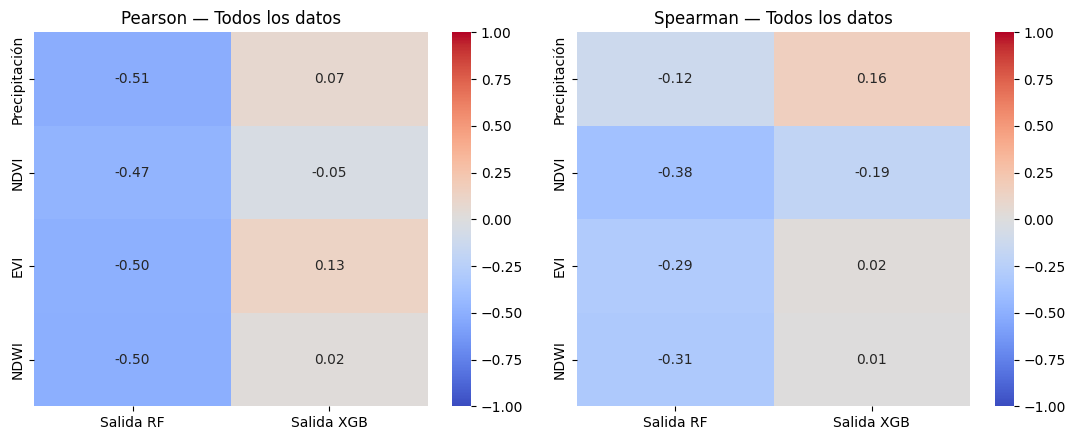

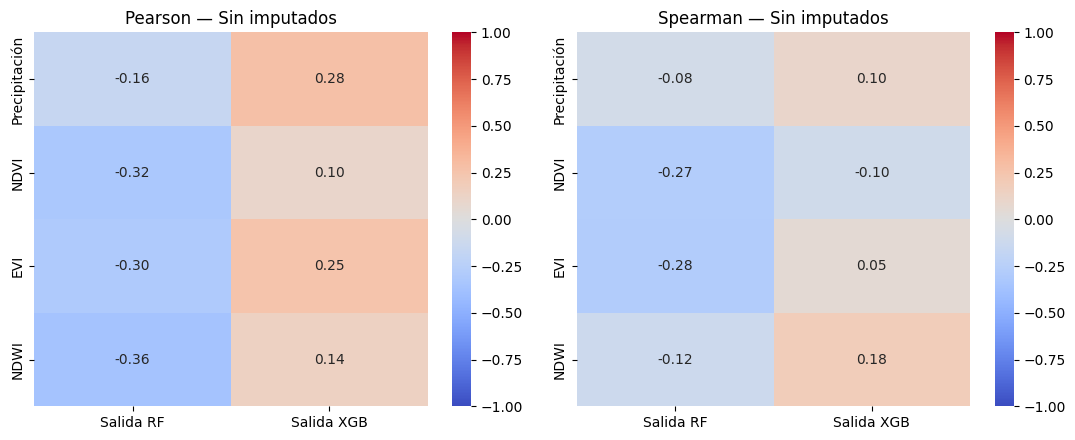

In [9]:
def matriz_variables_modelos(d, r, metodo):
    m = r["fold"] >= 0
    salidas = pd.DataFrame({"Salida RF": r["pred"]["Random Forest"][m], "Salida XGB": r["pred"]["XGBoost"][m]})
    filas = {ETIQ[v]: [pd.Series(d.loc[m, v].values).corr(salidas[c], method=metodo) for c in salidas.columns] for v in VARS}
    return pd.DataFrame(filas, index=salidas.columns).T

for etiqueta, d, r in [("Todos los datos", datos, res_todos), ("Sin imputados", sin_imp, res_sin)]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, met in zip(axes, ["pearson", "spearman"]):
        sns.heatmap(matriz_variables_modelos(d, r, met), annot=True, fmt=".2f", cmap="coolwarm",
                    center=0, vmin=-1, vmax=1, ax=ax)
        ax.set_title(f"{met.capitalize()} — {etiqueta}")
    plt.tight_layout(); plt.show()

## 6. Métricas de desempeño: MAE, RMSE y R²
Calculadas **solo sobre predicciones fuera de muestra cronológicas**. Se incluye un **baseline** (predecir la media del periodo de entrenamiento) como referencia.

- **MAE:** error absoluto medio (m).
- **RMSE:** raíz del error cuadrático medio (m); penaliza más los errores grandes.
- **R²:** 1 = perfecto, 0 ≈ igual que el baseline, negativo = peor que predecir la media.

In [10]:
def calcular_metricas(y, p):
    return {"MAE (m)": mean_absolute_error(y, p),
            "RMSE (m)": np.sqrt(mean_squared_error(y, p)),
            "R²": r2_score(y, p)}

def tabla_metricas(d, r):
    m = r["fold"] >= 0
    y = d.loc[m, "Nivel_Estatico_m"].values
    return pd.DataFrame({n: calcular_metricas(y, p[m]) for n, p in r["pred"].items()}).T.round(4)

print(f"TODOS LOS DATOS (n evaluado = {(res_todos['fold'] >= 0).sum()})"); met_todos = tabla_metricas(datos, res_todos);  display(met_todos)
print(f"SIN IMPUTADOS (n evaluado = {(res_sin['fold'] >= 0).sum()})");     met_sin   = tabla_metricas(sin_imp, res_sin); display(met_sin)

TODOS LOS DATOS (n evaluado = 44)


,MAE (m),RMSE (m),R²
Baseline (media),0.5367,0.6372,-0.2404
Random Forest,0.4643,0.5904,-0.0646
XGBoost,0.4520,0.5910,-0.0668


SIN IMPUTADOS (n evaluado = 34)


,MAE (m),RMSE (m),R²
Baseline (media),0.5979,0.6931,-0.2278
Random Forest,0.5140,0.6387,-0.0425
XGBoost,0.5398,0.6734,-0.1587


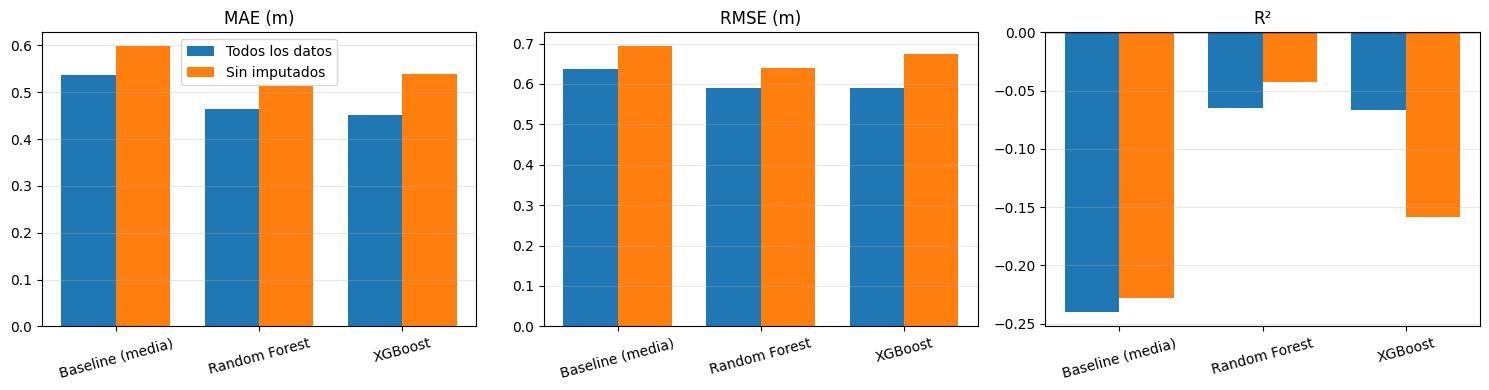

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["MAE (m)", "RMSE (m)", "R²"]):
    x = np.arange(len(met_todos)); ancho = 0.38
    ax.bar(x - ancho/2, met_todos[col], ancho, label="Todos los datos")
    ax.bar(x + ancho/2, met_sin[col],   ancho, label="Sin imputados")
    ax.set_xticks(x); ax.set_xticklabels(met_todos.index, rotation=15)
    ax.set_title(col); ax.grid(axis="y", alpha=.3)
    if col == "R²": ax.axhline(0, color="k", lw=1)
axes[0].legend(); plt.tight_layout(); plt.show()

### 6.1 Métricas por fold (todos los datos)

In [12]:
filas = []
y_all = datos["Nivel_Estatico_m"].values
for k, (tr, te) in enumerate(res_todos["splits"]):
    for nombre, p in res_todos["pred"].items():
        met = calcular_metricas(y_all[te], p[te])
        filas.append({"Fold": k + 1, "Modelo": nombre, "n_test": len(te), **met})
display(pd.DataFrame(filas).round(4).pivot(index="Fold", columns="Modelo", values=["MAE (m)", "RMSE (m)", "R²"]).round(3))

MAE (m)                               RMSE (m)                \
Modelo Baseline (media) Random Forest XGBoost Baseline (media) Random Forest   
Fold                                                                           
1                 0.440         0.449   0.450            0.520         0.531   
2                 0.832         0.814   0.759            0.949         0.920   
3                 0.471         0.304   0.205            0.477         0.322   
4                 0.357         0.104   0.279            0.364         0.112   
5                 0.388         0.335   0.356            0.427         0.363   

                             R²                        
Modelo XGBoost Baseline (media) Random Forest XGBoost  
Fold                                                   
1        0.534           -0.518        -0.584  -0.599  
2        0.871           -1.103        -0.977  -0.770  
3        0.276          -35.697       -15.659 -11.279  
4        0.474          -26.867        -1.614 -46.155  
5        0.416           -0.282         0.074  -0.218

## 7. Importancia de las variables
### 7.1 Importancia por permutación
Aumento del **MAE** (en metros) al barajar cada variable en los datos de prueba de cada fold, promediado entre folds.
Valores ≈ 0 o negativos = la variable no aporta al predecir periodos nuevos.

,Variable,RF_media,RF_desv,XGB_media,XGB_desv
0,Precipitacion_mm,-0.0092,0.0104,-0.0276,0.0147
1,NDVI,-0.0180,0.0285,-0.0538,0.0527
2,EVI,-0.0242,0.0655,-0.0384,0.0499
3,NDWI,-0.0069,0.0236,0.0008,0.0015


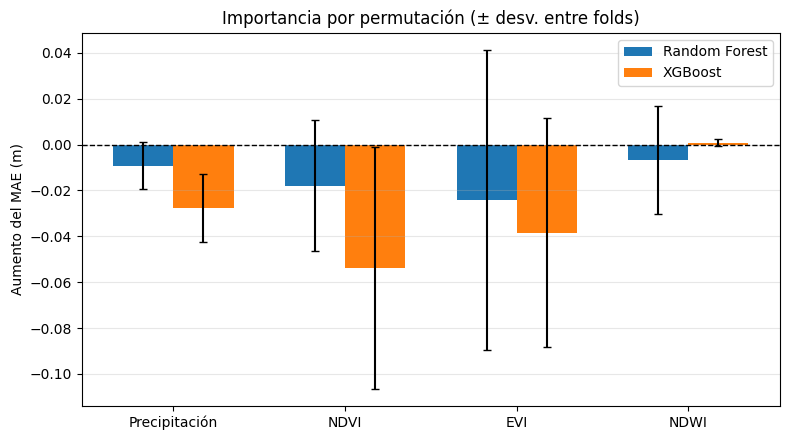

In [13]:
def importancia_permutacion(d, r):
    X, y = d[VARS].values, d["Nivel_Estatico_m"].values
    acum = {n: [] for n in crear_modelos()}
    for tr, te in r["splits"]:
        for nombre, mdl in crear_modelos().items():
            m = mdl.fit(X[tr], y[tr])
            pi = permutation_importance(m, X[te], y[te], n_repeats=30, random_state=RANDOM_STATE,
                                        scoring="neg_mean_absolute_error")
            acum[nombre].append(-pi.importances_mean)      # aumento de MAE
    return pd.DataFrame({
        "Variable": VARS,
        "RF_media":  np.mean(acum["Random Forest"], axis=0), "RF_desv":  np.std(acum["Random Forest"], axis=0),
        "XGB_media": np.mean(acum["XGBoost"], axis=0),       "XGB_desv": np.std(acum["XGBoost"], axis=0),
    }).round(4)

imp_perm = importancia_permutacion(datos, res_todos)
display(imp_perm)

fig, ax = plt.subplots(figsize=(8, 4.5)); x = np.arange(len(VARS)); ancho = 0.35
ax.bar(x - ancho/2, imp_perm["RF_media"],  ancho, yerr=imp_perm["RF_desv"],  capsize=3, label="Random Forest")
ax.bar(x + ancho/2, imp_perm["XGB_media"], ancho, yerr=imp_perm["XGB_desv"], capsize=3, label="XGBoost")
ax.axhline(0, ls="--", lw=1, color="k")
ax.set_xticks(x); ax.set_xticklabels([ETIQ[v] for v in VARS]); ax.set_ylabel("Aumento del MAE (m)")
ax.set_title("Importancia por permutación (± desv. entre folds)"); ax.grid(axis="y", alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

### 7.2 SHAP
SHAP descompone cada predicción en la contribución de cada variable. Los valores se calculan **fuera de muestra**
(en los datos de prueba de cada fold, con el modelo entrenado solo con el pasado) y luego se juntan.

- **Barras:** importancia global = promedio del valor absoluto de SHAP (en metros).
- **Beeswarm:** cada punto es una medición; el color indica si el valor de la variable es alto (rojo) o bajo (azul) y la posición horizontal
  indica si empuja la predicción hacia un nivel **mayor** (derecha) o **menor** (izquierda).

In [14]:
def shap_fuera_de_muestra(d, r):
    X_df, y = d[VARS], d["Nivel_Estatico_m"].values
    res = {n: {"sv": [], "X": []} for n in crear_modelos()}
    for tr, te in r["splits"]:
        for nombre, mdl in crear_modelos().items():
            m = mdl.fit(X_df.iloc[tr].values, y[tr])
            sv = shap.TreeExplainer(m).shap_values(X_df.iloc[te].values)
            res[nombre]["sv"].append(sv); res[nombre]["X"].append(X_df.iloc[te])
    return {n: (np.vstack(v["sv"]), pd.concat(v["X"]).rename(columns=ETIQ)) for n, v in res.items()}

shap_res = shap_fuera_de_muestra(datos, res_todos)

tabla_shap = pd.DataFrame({
    "Variable": VARS,
    "RF_SHAP_medio_abs (m)":  np.abs(shap_res["Random Forest"][0]).mean(axis=0),
    "XGB_SHAP_medio_abs (m)": np.abs(shap_res["XGBoost"][0]).mean(axis=0),
}).round(4)
display(tabla_shap)

,Variable,RF_SHAP_medio_abs (m),XGB_SHAP_medio_abs (m)
0,Precipitacion_mm,0.0307,0.0710
1,NDVI,0.0790,0.1086
2,EVI,0.0364,0.0476
3,NDWI,0.0521,0.0045


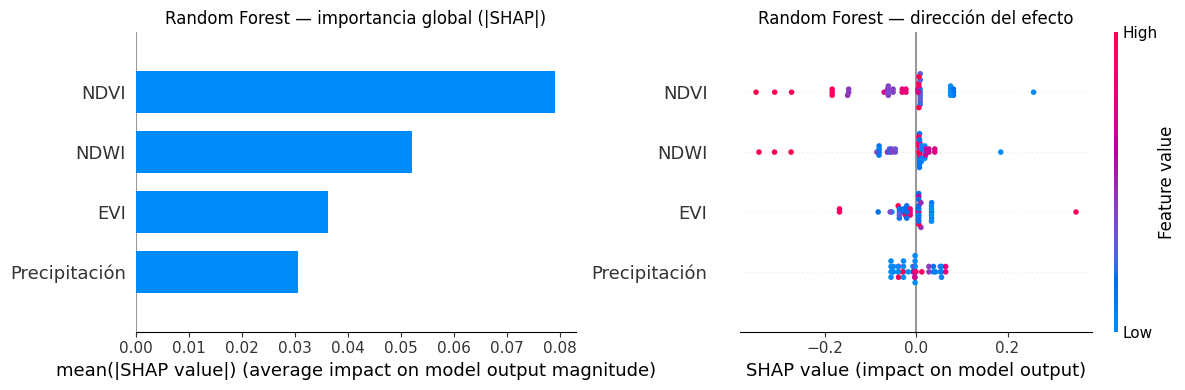

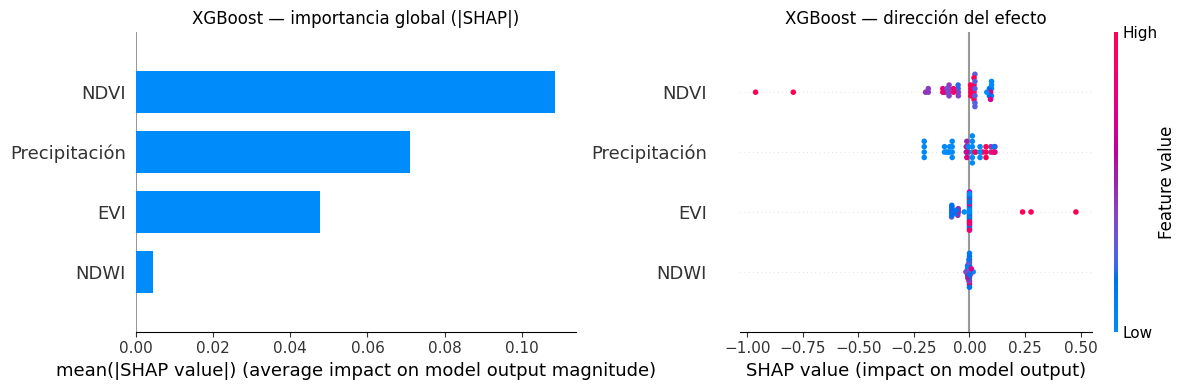

In [15]:
for nombre in ["Random Forest", "XGBoost"]:
    sv, Xs = shap_res[nombre]
    fig = plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); shap.summary_plot(sv, Xs, plot_type="bar", show=False, plot_size=None)
    plt.title(f"{nombre} — importancia global (|SHAP|)")
    plt.subplot(1, 2, 2); shap.summary_plot(sv, Xs, show=False, plot_size=None)
    plt.title(f"{nombre} — dirección del efecto")
    plt.tight_layout(); plt.show()

## 8. Tabla consolidada

In [16]:
corr_real = tabla_corr(datos)[["Variable", "Pearson_r", "Spearman_rho"]].rename(
    columns={"Pearson_r": "Nivel_Pearson_r", "Spearman_rho": "Nivel_Spearman_rho"})
tabla_final = (corr_real
               .merge(corr_mod_todos[["Variable", "RF_Pearson_r", "XGB_Pearson_r"]], on="Variable")
               .merge(imp_perm[["Variable", "RF_media", "XGB_media"]].rename(columns={"RF_media": "RF_Perm", "XGB_media": "XGB_Perm"}), on="Variable")
               .merge(tabla_shap.rename(columns={"RF_SHAP_medio_abs (m)": "RF_SHAP", "XGB_SHAP_medio_abs (m)": "XGB_SHAP"}), on="Variable"))
display(tabla_final.round(4))

,Variable,Nivel_Pearson_r,Nivel_Spearman_rho,RF_Pearson_r,XGB_Pearson_r,RF_Perm,XGB_Perm,RF_SHAP,XGB_SHAP
0,Precipitacion_mm,-0.0612,-0.0147,-0.5084,0.0723,-0.0092,-0.0276,0.0307,0.0710
1,NDVI,-0.2443,-0.3007,-0.4747,-0.0457,-0.0180,-0.0538,0.0790,0.1086
2,EVI,-0.1450,-0.2278,-0.4967,0.1306,-0.0242,-0.0384,0.0364,0.0476
3,NDWI,-0.2108,-0.2431,-0.5034,0.0206,-0.0069,0.0008,0.0521,0.0045


## 9. Resumen e interpretación (resultados de esta corrida)

**Validación:** `TimeSeriesSplit` cronológico (5 folds). Se evaluaron 44 de 51 filas (34 de 41 sin imputados); las primeras 7 solo sirven para entrenar.

**1. Correlación con el nivel estático real**
Relación débil y negativa. NDVI es la más consistente (Spearman ρ = -0.30; -0.36 sin imputados). La precipitación prácticamente no se relaciona (ρ ≈ -0.01).

**2. Correlación con la salida de los modelos (Pearson, todos los datos)**

| Variable | Random Forest | XGBoost |
|---|---|---|
| Precipitación | -0.51 | 0.07 |
| NDVI | -0.47 | -0.05 |
| EVI | -0.50 | 0.13 |
| NDWI | -0.50 | 0.02 |

Con validación cronológica el patrón **no es estable**: Random Forest muestra ≈ -0.5 con las cuatro variables (incluida la precipitación, que casi no se relaciona con el nivel real), mientras que XGBoost queda cerca de 0. Sin imputados los valores también cambian. La correlación con la salida de un modelo describe lo que ese modelo hace con las variables y no es evidencia independiente sobre el pozo; aquí, además, depende del modelo y del escenario.

**3. Métricas (fuera de muestra, cronológicas, todos los datos)**

| Modelo | MAE (m) | RMSE (m) | R² |
|---|---|---|---|
| Baseline (media del entrenamiento) | 0.537 | 0.637 | -0.240 |
| Random Forest | 0.464 | 0.590 | -0.065 |
| XGBoost | 0.452 | 0.591 | -0.067 |

Sin imputados: RF MAE 0.514 / RMSE 0.639 / R² -0.043; XGB MAE 0.540 / RMSE 0.673 / R² -0.159; baseline MAE 0.598 / RMSE 0.693 / R² -0.228.
Los modelos reducen algo el error frente al baseline (≈ 0.07-0.09 m de MAE), pero el R² sigue siendo ≤ 0: **no explican la variabilidad del nivel estático en periodos nuevos**. El R² por fold es muy inestable (valores muy negativos cuando el nivel casi no varía dentro del fold de prueba), por lo que se debe usar el global.

**4. Importancia de variables**
- **Permutación:** todos los valores son ≈ 0 o negativos (p. ej. NDVI: -0.018 m en RF, -0.054 m en XGB). Barajar las variables no empeora las predicciones en periodos nuevos: **no aportan información útil fuera de muestra**.
- **SHAP:** NDVI es la variable que más usa cada modelo (|SHAP| medio 0.079 m en RF y 0.109 m en XGB). La segunda difiere: NDWI en RF (0.052) y precipitación en XGB (0.071). Los efectos son pequeños (≲ 0.1 m) frente a la desviación del nivel (0.54 m). En RF, valores altos de NDVI empujan la predicción hacia un nivel menor (más somero), coherente con la correlación negativa.
- La diferencia entre SHAP (qué usa el modelo) y permutación (qué mejora la predicción) indica que los modelos se apoyan en el NDVI, pero ese uso no se traduce en mejores predicciones en el futuro.

**Conclusión:** la vegetación (NDVI) es la variable ambiental más asociada al nivel estático, de forma negativa y débil; la precipitación casi no aporta. Los modelos de ML reproducen esa jerarquía en SHAP, pero con validación cronológica no logran explicar el nivel del pozo en periodos nuevos. Los resultados se interpretan como asociaciones y no como causalidad.

**Limitaciones:** solo 2 datos ambientales por año (24 fechas ambientales distintas, 20 en el periodo evaluado); ~3 meses de distancia típica entre dato ambiental y medición; ~20 % de mediciones imputadas; un solo pozo; pocos datos para modelos de ML.